In [1]:
import timeit as t
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt
#### %matplotlib notebook
%matplotlib inline

# Setup styles for plotting
style_list = ['default', 'classic'] + sorted(
        style for style in plt.style.available if style != 'classic')
plt.style.use(style_list[10])
print(style_list)

['default', 'classic', 'Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
# 2.1 Function to find Nth Fibonacci term
def FibonacciRec(N:int):
    # Base Case
    if (N < 2):
        return N

    # Recursively computing the term
    # using recurrence relation
    return FibonacciRec(N - 1) + FibonacciRec(N - 2)

# Test fibonacci: compute results for N 1 .. 20
for n in range(0,20):
    print(n, " Fib:", FibonacciRec(n))


0  Fib: 0
1  Fib: 1
2  Fib: 1
3  Fib: 2
4  Fib: 3
5  Fib: 5
6  Fib: 8
7  Fib: 13
8  Fib: 21
9  Fib: 34
10  Fib: 55
11  Fib: 89
12  Fib: 144
13  Fib: 233
14  Fib: 377
15  Fib: 610
16  Fib: 987
17  Fib: 1597
18  Fib: 2584
19  Fib: 4181


### 2.2 Execution time

Example:
`t.timeit('quicksort(data)','from __main__ import data,quicksort', number = num)`


In [3]:
# Measure execution time : 
fibNumber = 40

t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)

print('Fibonnaci for ', fibNumber, ' execution time sec: ', t_fib)

Fibonnaci for  40  execution time sec:  22.387415800010785


[9.00006853e-07 1.40001066e-06 1.99989881e-06 1.31999841e-05
 1.47900078e-04 1.48699991e-03 1.64370000e-02 1.78176600e-01
 2.38783090e+00]


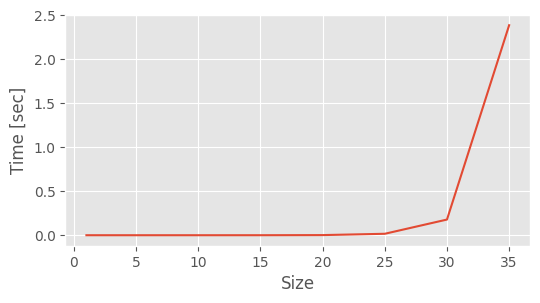

In [4]:
# 2.3 Plot graph of Fibonnaci execution time

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,20,25,30,35]
#
for n in n_list:
    fibNumber = n
    t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)
    t_list = np.append(t_list, t_fib)
print(t_list)


ax = plt.figure(figsize=[6,3])
plt.plot(n_list,t_list)
plt.xlabel('Size')
plt.ylabel('Time [sec]')
plt.show()


In [5]:
# 2.4 Class for algorithm testing
from utils import Algorithm

# Testing
a = Algorithm()
a.run()


Algorithm.run_once, operations:  10
 >>  0 , msec: 0.536 , operations:  10
 >>>  Algorithm  > Total run() sec:  0.0006059000734239817  Avg iter msec: 0.6059000734239817


{'name': 'Algorithm',
 'avg_msec': 0.6059000734239817,
 'avg_O': 10.0,
 'niter': 1,
 'output': []}

In [6]:
# 2.5  Fibonnaci algoritem z uporabo Alogrithm

class FibonacciRecursion(Algorithm):
    def __init__(self):
        self.name = "FibonacciRecursion"

    # Function to find Nth Fibonacci term
    def FibonacciR(self, N:int):
        # Count each call of the function
        self.count_op += 1

        # Base Case
        if (N < 2):
            return N

        # Recursively computing the term
        # using recurrence relation
        return self.FibonacciR(N - 1) + self.FibonacciR(N - 2)

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.FibonacciR(N)

        return self.result_data


s = FibonacciRecursion()
# calculate Fib. number of 10
s.data_params = {'N': 10}
# Test 10 times
print('Test result: ', s.run(10))


 >>  0 , msec: 0.055 , operations:  177
 >>  1 , msec: 0.057 , operations:  177
 >>  2 , msec: 0.052 , operations:  177
 >>  3 , msec: 0.061 , operations:  177
 >>  4 , msec: 0.048 , operations:  177
 >>  5 , msec: 0.045 , operations:  177
 >>  6 , msec: 0.050 , operations:  177
 >>  7 , msec: 0.048 , operations:  177
 >>  8 , msec: 0.059 , operations:  177
 >>  9 , msec: 0.048 , operations:  177
 >>>  FibonacciRecursion  > Total run() sec:  0.0014657999854534864  Avg iter msec: 0.14657999854534864
Test result:  {'name': 'FibonacciRecursion', 'avg_msec': 0.14657999854534864, 'avg_O': 177.0, 'niter': 10, 'output': 55}


 >>  0 , msec: 0.007 , operations:  1
 >>>  FibonacciRecursion  > Total run() sec:  0.0006998000899329782  Avg iter msec: 0.6998000899329782
 >>  0 , msec: 0.006 , operations:  5
 >>>  FibonacciRecursion  > Total run() sec:  7.349997758865356e-05  Avg iter msec: 0.07349997758865356
 >>  0 , msec: 0.006 , operations:  15
 >>>  FibonacciRecursion  > Total run() sec:  6.420002318918705e-05  Avg iter msec: 0.06420002318918705
 >>  0 , msec: 0.052 , operations:  177
 >>>  FibonacciRecursion  > Total run() sec:  0.00011470005847513676  Avg iter msec: 0.11470005847513676
 >>  0 , msec: 0.621 , operations:  1973
 >>>  FibonacciRecursion  > Total run() sec:  0.0006870999932289124  Avg iter msec: 0.6870999932289124
 >>  0 , msec: 6.459 , operations:  21891
 >>>  FibonacciRecursion  > Total run() sec:  0.006564900046214461  Avg iter msec: 6.564900046214461
 >>  0 , msec: 52.459 , operations:  242785
 >>>  FibonacciRecursion  > Total run() sec:  0.05252170003950596  Avg iter msec: 52.5217000395059

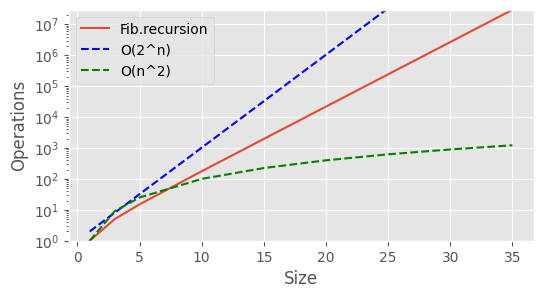

In [7]:
# 2.6 Testing Fibonacci recursion

size = np.array([]) #this array will store the current dataset size
t_list = np.array([]) #store processing time here
oper_list = np.array([]) #store processing operations here
num = 1 # evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,20,25,30,35]

s = FibonacciRecursion()
s.data_params = {'N': 1}

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])


ax = plt.figure(figsize=[6,3])
plt.plot(size, oper_list, label='Fib.recursion')

O2n = [2**n for n in n_list]
On2 = [n*n for n in n_list]
plt.plot(size, O2n, 'b--', label='O(2^n)')
plt.plot(size, On2, 'g--', label='O(n^2)')

plt.ylim([1, max(oper_list)])
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
plt.yscale('log')

plt.show()

In [8]:
# 2.7 Fibonnaci algorithm optimized

class FibonacciOptimized(Algorithm):
    def __init__(self):
        self.name = "FibonacciOptimized"

    # Function to find Nth Fibonacci term
    def Fibonacci(self, N):
        f=[0]*(N + 2)
        # 0th and 1st number of the
        # series are 0 and 1
        f[0] = 0
        f[1] = 1
        # Iterate over the range [2, N]
        for i in range(2,N+1) :
            self.count_op += 1
            # Add the previous 2 numbers
            # in the series and store it
            f[i] = f[i - 1] + f[i - 2]
        # Return Nth Fibonacci Number
        return f[N]

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.Fibonacci(N)

        return self.result_data


s = FibonacciOptimized()
s.data_params = {'N': 10000}
print(s.run(1))



 >>  0 , msec: 4.871 , operations:  9999
 >>>  FibonacciOptimized  > Total run() sec:  0.00513669999781996  Avg iter msec: 5.13669999781996
{'name': 'FibonacciOptimized', 'avg_msec': 5.13669999781996, 'avg_O': 9999.0, 'niter': 1, 'output': 3364476487643178326662161200510754331030214846068006390656476997468008144216666236815559551363373402558206533268083615937373479048386526826304089246305643188735454436955982749160660209988418393386465273130008883026923567361313511757929743785441375213052050434770160226475831890652789085515436615958298727968298751063120057542878345321551510387081829896979161312785626503319548714021428753269818796204693609787990035096230229102636813149319527563022783762844154036058440257211433496118002309120828704608892396232883546150577658327125254609359112820392528539343462090424524892940390170623388899108584106518317336043747073790855263176432573399371287193758774689747992630583706574283016163740896917842637862421283525811282051637029808933209990570792006436742620238

 >>  0 , msec: 0.004 , operations:  0
 >>>  FibonacciOptimized  > Total run() sec:  0.0001233000075444579  Avg iter msec: 0.12330000754445791
 >>  0 , msec: 0.007 , operations:  2
 >>>  FibonacciOptimized  > Total run() sec:  5.13000413775444e-05  Avg iter msec: 0.0513000413775444
 >>  0 , msec: 0.003 , operations:  4
 >>>  FibonacciOptimized  > Total run() sec:  3.3100019209086895e-05  Avg iter msec: 0.033100019209086895
 >>  0 , msec: 0.004 , operations:  9
 >>>  FibonacciOptimized  > Total run() sec:  2.859998494386673e-05  Avg iter msec: 0.02859998494386673
 >>  0 , msec: 0.005 , operations:  14
 >>>  FibonacciOptimized  > Total run() sec:  4.640000406652689e-05  Avg iter msec: 0.04640000406652689
 >>  0 , msec: 0.025 , operations:  99
 >>>  FibonacciOptimized  > Total run() sec:  5.1900045946240425e-05  Avg iter msec: 0.051900045946240425
 >>  0 , msec: 0.128 , operations:  499
 >>>  FibonacciOptimized  > Total run() sec:  0.00015590002294629812  Avg iter msec: 0.15590002294629812

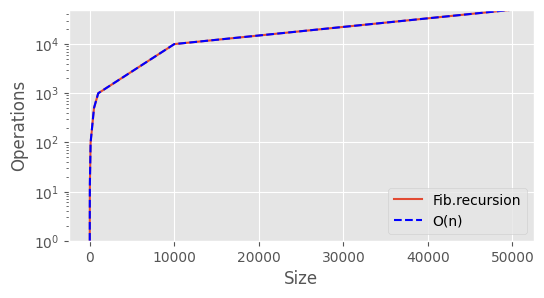

In [20]:
# 2.7 Testing Fibonacci optimized

size = np.array([]) #this array will store the current dataset size
t_list = np.array([]) #store processing time here
oper_list = np.array([]) #store processing operations here
num = 1 # evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,100,500,1000,10000,50000]

s = FibonacciOptimized()
s.data_params = {'N': 1}

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])


ax = plt.figure(figsize=[6,3])
plt.plot(size, oper_list, label='Fib.optimized')

On = [n for n in n_list]
#On2 = [n*n for n in n_list]
plt.plot(size, On, 'b--', label='O(n)')
#plt.plot(size, On2, 'g--', label='O(n^2)')

plt.ylim([1, max(oper_list)])
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
plt.yscale('log')

plt.show()


### Sorting algorithms

The task that we will be solving in this exercise will be a simple sorting of numbers in ascending order. Again when dealing with such a task, we must consider several scenarios (at least if we want to be objective in our measurements):
* **Optimal** - in this case the numbers are sorted allready, which means that the algorithm must only detect this as quick as possible.
* **Worst** - in this case the numbers are sorted but in a reverse order.
* **Normal** - the numbers are sorted randomly


In [10]:
def insertionSort2(array):
    d = array.copy()
    for j in range(1, len(d)):
        key = d[j]
        i = j - 1
        while i >= 0 and d[i] > key:
            d[i + 1] = d[i]
            i = i - 1
        d[i + 1] = key
    return d

In [11]:
# Create data set
def createSet(type = None, size = 100):
    if type == 1:  #return numbers sorted in ascening order -> best case
        return np.linspace(1,size,size).tolist() 
    elif type == 2: #return numbers in descending order -> wost case
        return np.linspace(size,1,size).tolist()
    else: #return a random assortment of numbers
        return (np.trunc(np.absolute(size*10/2.0 + size*10/5.0*np.random.randn(size)))/10).tolist()

In [12]:
# 3.1 Try type parameters : 1..3, print data
print("type=1 : ", createSet(1,20))


type=1 :  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]


In [13]:
# 3.3 Test insertionSort2
data = createSet(3, size=100)
result = insertionSort2(data)
print(data)
print(result)


[51.3, 52.5, 60.1, 29.7, 47.2, 45.2, 34.2, 48.2, 70.1, 42.8, 35.5, 26.8, 54.3, 21.5, 52.7, 41.1, 70.0, 31.3, 62.8, 44.4, 34.3, 27.1, 83.8, 54.4, 28.7, 49.7, 66.8, 66.2, 9.1, 7.9, 56.2, 34.8, 18.0, 53.6, 71.6, 30.8, 76.8, 38.8, 30.4, 46.0, 50.9, 62.1, 69.3, 0.3, 68.8, 29.6, 51.8, 39.6, 77.8, 77.6, 77.7, 45.5, 34.1, 41.1, 54.4, 48.2, 19.2, 57.9, 29.4, 54.6, 60.1, 57.2, 38.3, 52.9, 59.7, 62.1, 38.6, 83.0, 58.2, 37.8, 22.6, 72.3, 54.7, 63.2, 57.3, 69.3, 75.2, 47.8, 45.8, 13.2, 47.2, 28.6, 32.8, 44.2, 58.2, 66.6, 34.7, 55.7, 46.5, 71.0, 33.9, 71.5, 67.3, 53.3, 51.9, 67.1, 39.4, 27.3, 50.8, 35.9]
[0.3, 7.9, 9.1, 13.2, 18.0, 19.2, 21.5, 22.6, 26.8, 27.1, 27.3, 28.6, 28.7, 29.4, 29.6, 29.7, 30.4, 30.8, 31.3, 32.8, 33.9, 34.1, 34.2, 34.3, 34.7, 34.8, 35.5, 35.9, 37.8, 38.3, 38.6, 38.8, 39.4, 39.6, 41.1, 41.1, 42.8, 44.2, 44.4, 45.2, 45.5, 45.8, 46.0, 46.5, 47.2, 47.2, 47.8, 48.2, 48.2, 49.7, 50.8, 50.9, 51.3, 51.8, 51.9, 52.5, 52.7, 52.9, 53.3, 53.6, 54.3, 54.4, 54.4, 54.6, 54.7, 55.7, 56.2, 57

In [14]:
# Measurement class for algorithm complexity, insertion sort

class InsertionSort(Algorithm):
    def __init__(self):
        self.name = "Insertion Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()

    def insertionSort(self, array):
        d = array.copy()
        for j in range(1, len(d)):
            key = d[j]
            i = j - 1
            while i >= 0 and d[i] > key:
                self.count_op+=1
                d[i + 1] = d[i]
                i = i - 1
            d[i + 1] = key
        return d


    def run_once(self):
        self.result_data = self.insertionSort(self.input_data)
        return self.result_data

In [15]:
# 3.4 Test InsertionSort class

s = InsertionSort()
s.data_params = {'size': 1000, 'type': 2}

test_results = s.run(2)


print('Unsorted data: ', s.input_data)
#print('Sorted data: ', s.result_data)

print('\n TEST RESULTS :  ', test_results)


 >>  0 , msec: 99.234 , operations:  499500
 >>  1 , msec: 96.663 , operations:  499500
 >>>  Insertion Sort  > Total run() sec:  0.19640580005943775  Avg iter msec: 98.20290002971888
Unsorted data:  [1000.0, 999.0, 998.0, 997.0, 996.0, 995.0, 994.0, 993.0, 992.0, 991.0, 990.0, 989.0, 988.0, 987.0, 986.0, 985.0, 984.0, 983.0, 982.0, 981.0, 980.0, 979.0, 978.0, 977.0, 976.0, 975.0, 974.0, 973.0, 972.0, 971.0, 970.0, 969.0, 968.0, 967.0, 966.0, 965.0, 964.0, 963.0, 962.0, 961.0, 960.0, 959.0, 958.0, 957.0, 956.0, 955.0, 954.0, 953.0, 952.0, 951.0, 950.0, 949.0, 948.0, 947.0, 946.0, 945.0, 944.0, 943.0, 942.0, 941.0, 940.0, 939.0, 938.0, 937.0, 936.0, 935.0, 934.0, 933.0, 932.0, 931.0, 930.0, 929.0, 928.0, 927.0, 926.0, 925.0, 924.0, 923.0, 922.0, 921.0, 920.0, 919.0, 918.0, 917.0, 916.0, 915.0, 914.0, 913.0, 912.0, 911.0, 910.0, 909.0, 908.0, 907.0, 906.0, 905.0, 904.0, 903.0, 902.0, 901.0, 900.0, 899.0, 898.0, 897.0, 896.0, 895.0, 894.0, 893.0, 892.0, 891.0, 890.0, 889.0, 888.0, 887.0, 

In [16]:
# 3.5 Complexity of Insertion sort

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
oper_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,10,20,50,100, 200, 500, 1000,3000]

s = InsertionSort()
s.data_params['type'] = 3

# Loop over all dataset sizes
for n in n_list:
    s.data_params['size'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])

# Plot graph





 >>  0 , msec: 0.074 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  0.0001846000086516142  Avg iter msec: 0.1846000086516142
 >>  0 , msec: 0.024 , operations:  14
 >>>  Insertion Sort  > Total run() sec:  5.0200033001601696e-05  Avg iter msec: 0.050200033001601696
 >>  0 , msec: 0.034 , operations:  106
 >>>  Insertion Sort  > Total run() sec:  5.859998054802418e-05  Avg iter msec: 0.05859998054802418
 >>  0 , msec: 0.186 , operations:  741
 >>>  Insertion Sort  > Total run() sec:  0.00021050008945167065  Avg iter msec: 0.21050008945167065
 >>  0 , msec: 0.449 , operations:  2468
 >>>  Insertion Sort  > Total run() sec:  0.0004746000049635768  Avg iter msec: 0.4746000049635768
 >>  0 , msec: 1.569 , operations:  9373
 >>>  Insertion Sort  > Total run() sec:  0.001595799927599728  Avg iter msec: 1.595799927599728
 >>  0 , msec: 12.241 , operations:  61351
 >>>  Insertion Sort  > Total run() sec:  0.01229869993403554  Avg iter msec: 12.29869993403554
 >>  0 , msec: 54.575 , 

In [17]:
def quicksort(arr):
    """ Quicksort a list

    :type arr: list
    :param arr: List to sort
    :returns: list -- Sorted list
    """
    if len(arr) <= 1:
        return arr
    else:
        return quicksort([x for x in arr[1:] if x<arr[0]]) + [arr[0]] + quicksort([x for x in arr[1:] if x>=arr[0]])

In [18]:
class QuickSort(Algorithm):
    def __init__(self):
        self.name = "Quick Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()


    # Function to find the partition position
    def partition(self, array, low, high):
    
        # Choose the rightmost element as pivot
        pivot = array[high]
    
        # Pointer for greater element
        i = low - 1
    
        # Traverse through all elements
        # compare each element with pivot
        for j in range(low, high):
            if array[j] <= pivot:
    
                # If element smaller than pivot is found
                # swap it with the greater element pointed by i
                i = i + 1
    
                # Swapping element at i with element at j
                (array[i], array[j]) = (array[j], array[i])
                self.count_op+=1
    
        # Swap the pivot element with
        # the greater element specified by i
        (array[i + 1], array[high]) = (array[high], array[i + 1])
        self.count_op+=1
    
        # Return the position from where partition is done
        return i + 1
 
 
    # Function to perform quicksort
    def quicksort(self, array, low, high):
        if low < high:
    
            # Find pivot element such that
            # element smaller than pivot are on the left
            # element greater than pivot are on the right
            pi = self.partition(array, low, high)
    
            # Recursive call on the left of pivot
            self.quicksort(array, low, pi - 1)
    
            # Recursive call on the right of pivot
            self.quicksort(array, pi + 1, high)


    def run_once(self):
        N = len(self.input_data)
        self.result_data = self.quicksort(self.input_data, 0, N-1)
        return self.result_data

In [19]:
# 3.6 Code testing Quick sort



